# Notebook 4 — Baseline Models
This notebook trains the baseline classifiers (Random Forest and XGBoost) using the project's model module. We compute core validation metrics and compare both models visually through feature importance and ROC curves.

## Imports and data loading
We load engineered train/validation splits and prepare feature matrices.

The following cell uses the same column drop logic as the training pipeline.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, roc_curve

cwd = Path.cwd()
project_root = cwd if (cwd / "src").exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.baseline import DROP_COLS, train_random_forest, train_xgboost

proc = project_root / "data" / "processed"
train_df = pd.read_csv(proc / "train_engineered.csv", parse_dates=["timestamp"])
val_df = pd.read_csv(proc / "val_engineered.csv", parse_dates=["timestamp"])

drop_cols = [c for c in DROP_COLS if c in train_df.columns]
X_train_full = train_df.drop(columns=drop_cols)
y_train_full = train_df["failure_within_48h"]
X_val = val_df.drop(columns=drop_cols)
y_val = val_df["failure_within_48h"]

print("Train shape:", X_train_full.shape, "| Val shape:", X_val.shape)

Train shape: (859677, 95) | Val shape: (183985, 95)


## Train baselines
To keep notebook runtime practical, we train on a reproducible sample from the full engineered training set.

In [2]:
X_train = X_train_full.sample(n=min(120000, len(X_train_full)), random_state=42)
y_train = y_train_full.loc[X_train.index]

rf = train_random_forest(X_train, y_train)
xgb = train_xgboost(X_train, y_train)

print("Models trained:", type(rf).__name__, "and", type(xgb).__name__)

✅ Random Forest trained.


C:\Users\avarg\OneDrive\Documentos\proyect-PMA\predictive-maintenance-automotive\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:27:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost trained.
Models trained: RandomForestClassifier and XGBClassifier


In [3]:
rf_prob = rf.predict_proba(X_val)[:, 1]
xgb_prob = xgb.predict_proba(X_val)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)
xgb_pred = (xgb_prob >= 0.5).astype(int)

metrics_table = pd.DataFrame(
    [
        {
            "Model": "Random Forest",
            "Precision": precision_score(y_val, rf_pred, zero_division=0),
            "Recall": recall_score(y_val, rf_pred, zero_division=0),
            "F1": f1_score(y_val, rf_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_val, rf_prob),
        },
        {
            "Model": "XGBoost",
            "Precision": precision_score(y_val, xgb_pred, zero_division=0),
            "Recall": recall_score(y_val, xgb_pred, zero_division=0),
            "F1": f1_score(y_val, xgb_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_val, xgb_prob),
        },
    ]
).set_index("Model")

display(metrics_table.style.format("{:.4f}"))

,Precision,Recall,F1,ROC-AUC
Model,,,,
Random Forest,0.9959,0.9776,0.9867,0.9983
XGBoost,0.9893,0.9836,0.9864,0.9988


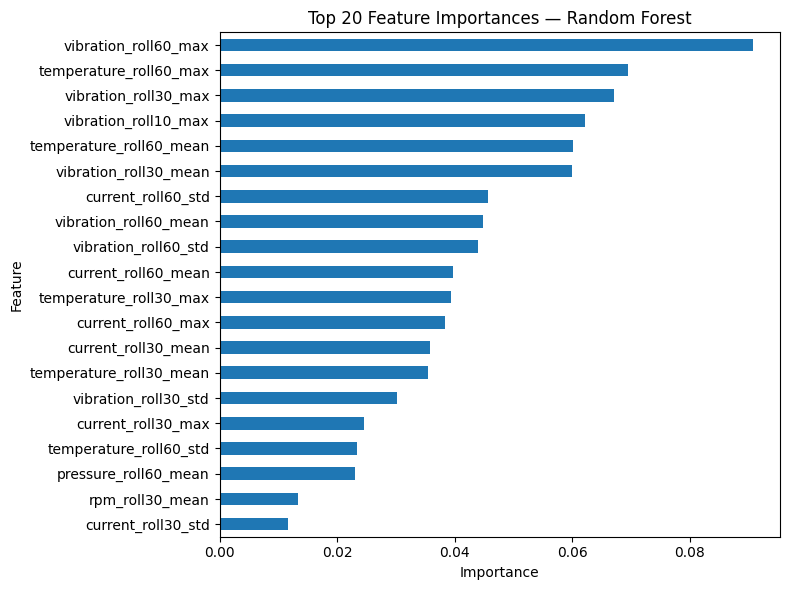

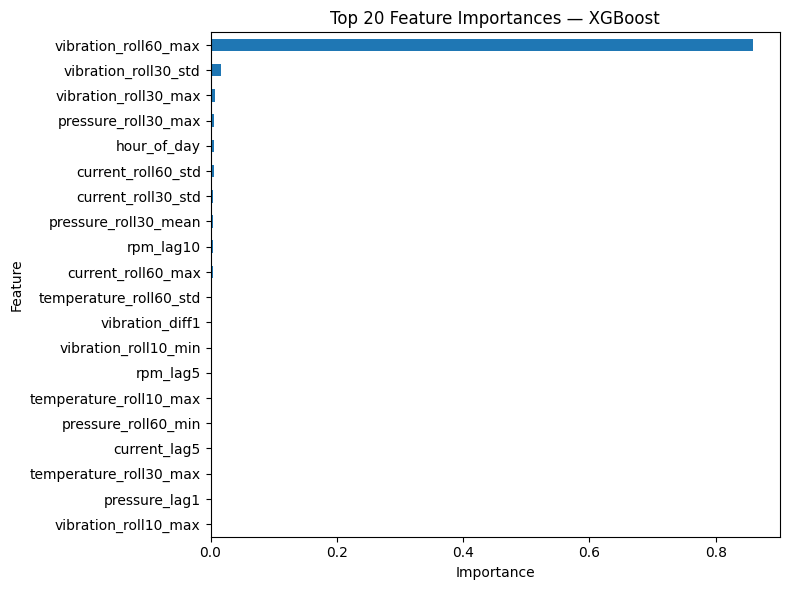

In [4]:
def plot_top_importance(model, name, feature_names, top_n=20):
    imp = pd.Series(model.feature_importances_, index=feature_names).nlargest(top_n).sort_values()
    plt.figure(figsize=(8, 6))
    imp.plot(kind="barh")
    plt.title(f"Top {top_n} Feature Importances — {name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

plot_top_importance(rf, "Random Forest", X_train.columns, top_n=20)
plot_top_importance(xgb, "XGBoost", X_train.columns, top_n=20)

## ROC comparison
ROC curves summarize ranking quality across thresholds for both baseline models.

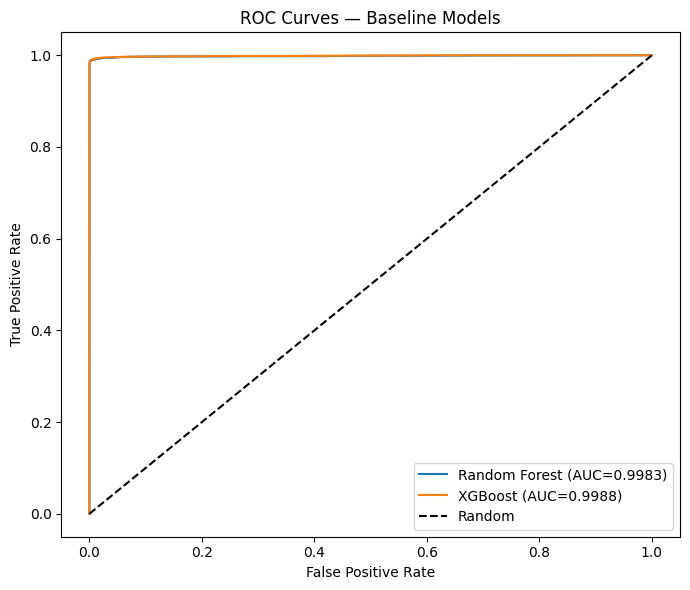

In [5]:
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, xgb_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_val, rf_prob):.4f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_score(y_val, xgb_prob):.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.title("ROC Curves — Baseline Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

Baseline training and validation comparison are complete. The next notebook focuses on sequence modeling with LSTM.